# **SPECTRA v2**

In [1]:
%load_ext autoreload
%autoreload 2

import os
import torch
import json
import networkx as nx
from matplotlib import pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import anndata as ad

import warnings
warnings.filterwarnings("ignore")

# torch device setting
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(device)

12.1
Tesla V100-SXM2-32GB
cuda


In [2]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/michele.calabro/.netrc.
wandb: Currently logged in as: michi-geco97 (michi-geco97-politecn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

**NOTE:** put `add_control=True` to **concatenate** to the generated, syntetic dataset `pred_adata` the **ground truth control cells**. Why? Because we need them to calculate DEGs 

### **Data import**
**filtering and normalization**: quite standard, we remove perturbations with less than 100 samples (can be changed)

In [29]:
# data loading and filtering
adata = sc.read_h5ad('../data/vcc_data/adata_Training.h5ad') #VCC
#adata = sc.read_h5ad('data/K562_gwps_raw_singlecell_01.h5ad') # replogle
adata

AnnData object with n_obs × n_vars = 221273 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'gene_id'

In [3]:
# var_names rename for replogle
adata.var['gene_name'] = adata.var['gene_name'].astype('string')
adata.var_names = adata.var['gene_name']
adata.var_names_make_unique()

In [30]:
from utils import data_preprocessing

adata = data_preprocessing(adata, 'gene', 'non-targeting', logtransform=True, min_cells_per_pert=100)
adata

View of AnnData object with n_obs × n_vars = 220998 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [5]:
# filtering for replogle
gene_list = pd.read_csv('/scratch/michele.calabro/gears/VCC/SPECTRA/data/replogle_2022_5k_genes_mapped.csv')
gene_list = gene_list['gene_name']
gene_list = gene_list.tolist()
mask = adata.var_names.isin(gene_list)
adata = adata[:, mask]
adata

View of AnnData object with n_obs × n_vars = 1869462 × 4999
    obs: 'gem_group', 'target_gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'n_genes'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells'
    uns: 'log1p'

In [31]:
import pickle

with open("scGPT_embeddings_all_genes.pkl", "rb") as f:
    scgpt_dict = pickle.load(f)

### **GRN preparation**

***
### Patrick stuff

In [32]:
# patrick guanlab (stock)
A = np.load('Patrick_networks/Hierarchist_14_adjacency.npz') #guanlab_stock_3.5k_directed.npz
adjacency = A['adjacency']
gene_names = A['gene_names']

# Create weighted DiGraph (parallel_edges=False treats values as weights)
G = nx.from_numpy_array(
    adjacency,
    parallel_edges=False,
    create_using=nx.DiGraph(),
    edge_attr='weight',  # Attribute name for weights
)

# Relabel nodes with gene names (must be same length as matrix dims)
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)

G.remove_nodes_from([n for n in G.nodes if n not in scgpt_dict])
#G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if np.log(d['weight']+1) < 10])


num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filter adata
gene_list = list(G.nodes())
mask = adata.var_names.isin(gene_list)
adata = adata[:, mask]
adata

Number of nodes: 3342
Number of edges: 12564
Number of node features per node: 1


View of AnnData object with n_obs × n_vars = 220998 × 3342
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

### End of patrick stuff
***

### Replogle SCENIC grn

In [ ]:
# network file
with open('../SCENIC_GRNs/SCENIC_GRNs/networks/repogle_network.json', 'r') as json_file:
    network = json.load(json_file)
    
# Create the networkx graph
G = nx.DiGraph()
for tf, targets in network.items():
    for target, weight in targets:
        G.add_edge(tf, target, weight=weight)

G.remove_nodes_from([n for n in G.nodes if n not in scgpt_dict])

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
gene_list = list(G.nodes)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filtering data to gene contained in the network G
adata.var_names = adata.var['gene_name'].astype(str)
adata.var_names_make_unique()
adata = adata[:, adata.var_names.isin(gene_list)]

# perturbation filtering
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = [pert for pert in perturbations if not pert in gene_list]
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

# adata rows shuffle (otherwise perturbations are all ordered)
adata = adata[np.random.permutation(adata.n_obs), :].copy()
adata

***

### GRNBoost2 network

In [7]:
# load GRN
network_data = pd.read_csv('../SCENIC_GRNs/SCENIC_GRNs/temp_results/replogle_adjacencies_vcc.tsv', sep='\t')

# Create the networkx graph
G = nx.DiGraph()
for i in range(network_data.shape[0]):
    edge = network_data.iloc[i,:]
    if np.abs(edge['importance'])>0.2: #TODO: dumb pruning, make somehting better please
        G.add_edge(edge['TF'], edge['target'], weight=edge['importance'])

G.remove_nodes_from([n for n in G.nodes if n not in scgpt_dict])
gene_list = list(G.nodes)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

Number of nodes: 4903
Number of edges: 108009
Number of node features per node: 1


In [8]:
# filtering data to gene contained in the network G
adata = adata[:, adata.var_names.isin(gene_list)]

# perturbation filtering
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = [pert for pert in perturbations if not pert in gene_list]
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

# adata rows shuffle (otherwise perturbations are all ordered)
adata = adata[np.random.permutation(adata.n_obs), :]
adata

View of AnnData object with n_obs × n_vars = 917355 × 4903
    obs: 'gem_group', 'target_gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'n_genes'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells'
    uns: 'log1p'

***

**Once loaded the network file**, check compatibility with the dataset variables and relabel the nodes

In [33]:
# check if the node names of th enwtrokx graph aorresponds to adata.var_names
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

# relabel networkx node indices to match the adata
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}

edges = [(gene_to_idx[u], gene_to_idx[v]) for u, v in G.edges()] #this forces edge_index to match the order of adata.var_names
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# G = nx.relabel_nodes(G, gene_to_idx)
# edge_index = from_networkx(G, group_edge_attrs='all').edge_index # this way, edge_index follows the gene order of adata.var_names

Hyperparameters and wandb setup:

In [34]:
# here we put all the hyperparameters, metadata and stuff
config = dict(
    dataset_size=adata.shape[0],#(adata.obs['target_gene'] != 'non-targeting').sum(),
    test_ratio=0.2,
    val_ratio=0.1,
    batch_size=64,
    n_channels=8,
    dropout_p=0.23217682427428007,
    num_node_features=1,
    lr=0.001,
    n_epochs=20,
    alpha = 0.11777899412267034,
    beta = 0.001,
    dataset="vcc",
    architecture="FAGCN_FiLM")

In [35]:
# map genes to gene names for scGPT
scgpt_dict = {gene_to_idx[k]: v for k, v in scgpt_dict.items() if k in gene_to_idx}

# embedding lookup table
scgpt_dim = len(next(iter(scgpt_dict.values())))
embedding_matrix = torch.zeros((num_nodes, scgpt_dim))
for gene_id, emb in scgpt_dict.items():
    embedding_matrix[gene_id] = torch.tensor(emb, dtype=torch.float32)


In [36]:
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
pert_to_idx = {pert: i for i, pert in enumerate(perturbations)}
config['pert_to_idx']=pert_to_idx

### **Dataloaders preparation**
Compared with the original SPECTRA model, here we should calculate the dataloaders so that in each batch there are only samples taken from the same perturbations.

**NOTE**: currently the split is random cell-wise, if we want to esclude some perturbations, I think it's enough to sort the dataset by column `target_gene`

In [37]:
from utils import build_model_dataloaders_split_perturbs

train_loader, val_loader, test_loader, train_size, test_size, _, train_adata, _, test_adata = build_model_dataloaders_split_perturbs(adata, config)

Total Unique Perturbations: 145
Train set: 102 perts | 130660 cells
Val set: 14 perts | 16701 cells
Test set: 29 perts | 35461 cells


Weights based on (gorund-truth) DEGs:

In [38]:
#NOTE: new DEGs weights
from WMSE import compute_weights

gene_weights = compute_weights(train_adata, gene_to_idx, cells_per_pert=256)

Calculating WMSE Weights: 100%|██████████| 102/102 [00:00<00:00, 1759.96it/s]


In [14]:
# load gene weights
import pickle

with open('gene_weights_replogle_new.pkl', 'rb') as f:
    gene_weights = pickle.load(f)
print(type(gene_weights))

<class 'dict'>


### **Model setup**

In [16]:
wandb.init(
    project="SPECTRA",       # The name of your project in wandb
    name=config['architecture'],   # (Optional) Name of this specific run
    config=config               # Pass your dictionary here!
)

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [39]:
from spectra_v2_fagcn import PerturbModel

model = PerturbModel(
    edge_index, 
    num_nodes, 
    device, 
    config = config,
    gene_embeddings = embedding_matrix,
    gene_weights=gene_weights
)
model = model.to(device)
print(model)

number of trainable parameters: 219089
PerturbModel(
  (gene_embeddings): Embedding(3342, 512)
  (project_gene): Linear(in_features=512, out_features=8, bias=True)
  (project_expr): Linear(in_features=1, out_features=8, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=8, bias=True)
    (shift): Linear(in_features=1, out_features=8, bias=True)
  )
  (add_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (ko_mu): Embedding(3342, 64)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Linear(in_features=64, out_features=8, bias=True)
      (2): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=8, out_features=8, bias=True)
      (6): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (proj_mu): 

In [40]:
idx_to_gene = {v: k for k, v in gene_to_idx.items()}

In [15]:
from spectra_v2_fagcn import train
_, _, test_wmse = train(model=model, 
    train_loader=train_loader, 
    test_loader=val_loader,
    lr=config['lr'], 
    n_epochs=config['n_epochs'],  
    device=device,
    wandb_support=False,
    var_names = adata.var_names.tolist(),
    idx_to_gene = idx_to_gene,
    alpha_weight=config['alpha'],   # Injected from Sweep
    beta_weight=config['beta'],     # Injected from Sweep
)

training at epoch 1: 100%|██████████| 2674/2674 [17:17<00:00,  2.58it/s]


training KL = 0.64853 | mse = 0.120 | cos = 0.929


testing...: 100%|██████████| 342/342 [00:13<00:00, 24.87it/s]


Validation metric improved to 3.0001. Saving best model...


training at epoch 2: 100%|██████████| 2674/2674 [17:04<00:00,  2.61it/s]


...

training KL = 2.15415 | mse = 0.004 | cos = 0.783


testing...: 100%|██████████| 342/342 [00:13<00:00, 24.86it/s]


No improvement. Patience: 5/5
Early stopping triggered! No improvement for 5 epochs.

--- Training concluded. Initiating Final Evaluation ---
Reloading best epoch weights for final evaluation...


testing with AUPRC...:   0%|          | 0/342 [00:00<?, ?it/s]


ValueError: too many values to unpack (expected 3)

In [16]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train/cosine_loss,█▇▅▄▃▂▂▁▁▁▁▁▁▁▁
train/global_loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁
train/kl_divergence,▁▂▂▃▅▇██████▇▇█
train/mmd_ctrl,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mmd_pert,█▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train/mse,█▅▃▂▂▁▁▁▁▁▁▁▁▁▁
val/AUPRC,▁
val/test_MMD,█▄▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,15
train/cosine_loss,0.77338


In [14]:
torch.save(model.state_dict(), "test_DirGNN_Cheb_fungi.pth")

***

# **Testing**

In [44]:
model.load_state_dict(torch.load("weights/best_model_FAGCN_FiLM_d9brrwwt.pth"))

<All keys matched successfully>

In [45]:
model.eval()

PerturbModel(
  (gene_embeddings): Embedding(3342, 512)
  (project_gene): Linear(in_features=512, out_features=8, bias=True)
  (project_expr): Linear(in_features=1, out_features=8, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=8, bias=True)
    (shift): Linear(in_features=1, out_features=8, bias=True)
  )
  (add_norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (ko_mu): Embedding(3342, 64)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Linear(in_features=64, out_features=8, bias=True)
      (2): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=8, out_features=8, bias=True)
      (6): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (proj_mu): Linear(in_features=8, out_features=8, b

### **Attention network analysis**

In [28]:
# Assuming you have loaded your trained model weights...
model.eval()

# Grab a single batch (e.g., TP53 knockouts) - NOTE: this is just an example
x,y,pert, pert_idx = next(iter(test_loader)) 

# Get the attention matrices
A_Agg, _, _ = model((x,pert), return_attention_weights=True)

# perturbation 
pert = pert[0]
index = torch.nonzero(pert).squeeze().numpy()
perturbed_gene = idx_to_gene[index.item()]
print(perturbed_gene)
print('============')

# Shows where information originates from Node $i$ and travels to other nodes 
shockwaves={idx_to_gene[i]:A_Agg[index, i] for i in range(A_Agg.shape[0])}

# Inspect the shockwave - Sort keys by descending absolute value, take top 10
top_10_keys = sorted(shockwaves, 
                    key=lambda k: abs(shockwaves[k]), 
                    reverse=True)[:10]
top_10_dict = {k: shockwaves[k].item() for k in top_10_keys}
print(top_10_dict)

# building networkx digraph from adjacency matrix
attention_graph = nx.from_numpy_array(A_Agg.cpu().numpy(), create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)

STAT1
{'TUBB2A': -1.0663738250732422, 'NME4': -1.041610598564148, 'PTMS': -0.9876031875610352, 'TMSB10': -0.97699373960495, 'NREP': -0.9769649505615234, 'MDK': -0.967029869556427, 'POU5F1': -0.9481310248374939, 'CD24': -0.910582423210144, 'PSAT1': -0.6615120768547058, 'ZIC5': -0.6454126238822937}


Build the test adata `real_adata`- last n rows of the entire dataset (NOTE: adjust if needed)

In [18]:
n_cells = test_size
real_adata = adata[-n_cells:, :]
n_min_samples = 200

counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= n_min_samples]
gene_counts_dict = counts.drop('non-targeting').to_dict() # creation of dict: for each pertuyrbation how many cells to generate
real_adata = real_adata[real_adata.obs['target_gene'].isin(counts.index)]
real_adata

View of AnnData object with n_obs × n_vars = 18658 × 3342
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [46]:
# for perturbation split
real_adata = test_adata
n_min_samples = 50
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= n_min_samples]
gene_counts_dict = counts.drop('non-targeting').to_dict() # creation of dict: for each pertuyrbation how many cells to generate
real_adata = real_adata[real_adata.obs['target_gene'].isin(counts.index)]
real_adata

View of AnnData object with n_obs × n_vars = 43096 × 3342
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'

The dictionary `gene_count_dict` contains, for each perturbation, **the number of cells we want the model to generate with that perturbation**. Above, we have set the abundance of cells for each perturbation to be the same as in `real adata`.

This dictionary is the **main input** to be passed to spectra in order to generate a synthetic Perturb-seq dataset, as show in the next cell:

**NOTE:** put `add_control=True` to **concatenate** to the generated, syntetic dataset `pred_adata` the **ground truth control cells**. Why? Because we need them to calculate DEGs 

In [47]:
from utils import generate_adata_from_control

pred_adata = generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, real_adata.var_names, add_control=True)
pred_adata

100%|██████████| 29/29 [00:16<00:00,  1.71it/s]


AnnData object with n_obs × n_vars = 43096 × 3342
    obs: 'target_gene'

# **Benchmark and evaluation metrics**

First thing first, a **baseline** is needed:
* for each perturbation *already seen* during training, we return the average gene expression of all the samples in the training data (`adata[:train_size,:]`) with that perturbation label
* for perturbations *NOT seen* suring training, we return the average of the average of gene expressions for all perturbations (very naive baseline but it's very popular in most benchmark)

In [48]:
from utils import generate_adata_baseline

pred_adata_2 = generate_adata_baseline(gene_counts_dict, train_adata, real_adata.var_names) #adata[:train_size,:]

# Append the non-targeting controls to the example anndata if they're missing
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]
if "non-targeting" not in pred_adata_2.obs["target_gene"].unique():
    assert np.all(pred_adata_2.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata_2 = ad.concat(
        [
            pred_adata_2,
            ntc_adata,
        ]
    )
del ntc_adata
pred_adata_2

100%|██████████| 29/29 [00:00<00:00, 171.26it/s]


AnnData object with n_obs × n_vars = 43096 × 3342
    obs: 'target_gene'

In [26]:
import anndata as ad

ad.settings.allow_write_nullable_strings = True

In [70]:
real_adata.write('results/real_adata2.h5ad')
pred_adata.write('results/pred_adata-chocolate_sweep.h5ad')
pred_adata_2.write('results/pred_adata-baseline_vcc.h5ad')

#### Old metrics:

In [73]:
from benchmark import process_datasets

process_datasets('results/real_adata2.h5ad', ['results/pred_adata-baseline_vcc.h5ad', 'results/pred_adata-chocolate_sweep.h5ad'], 50,
        ['mse', 'pcc_delta', 'edistance', 'f1', 'auprc', 'common_degs'])

[*] Loading real dataset from: results/real_adata2.h5ad
[*] Loading prediction for model 'baseline_vcc': pred_adata-baseline_vcc.h5ad
    -> Calculating mse...


    -> Calculating pcc_delta...


    -> Calculating edistance...


    -> Calculating f1...


100%|██████████| 29/29 [01:18<00:00,  2.72s/it]


...

100%|██████████| 29/29 [01:18<00:00,  2.72s/it]


    -> Calculating auprc...


100%|██████████| 29/29 [02:56<00:00,  6.09s/it]



--- Summary ---
Average Baseline AUPRC: 0.0539
Average Model AUPRC:    0.0991
    -> Calculating common_degs...


{'mse': {'baseline_vcc': {'AKT2': np.float64(0.0396),
   'CAMSAP2': np.float64(0.0059),
   'TWF2': np.float64(0.0193),
   'SAFB': np.float64(0.0538),
   'MAP3K7': np.float64(0.018),
   'STAG2': np.float64(0.1031),
   'USP22': np.float64(0.0507),
   'SMAGP': np.float64(0.0371),
   'KIF1B': np.float64(0.0276),
   'XRCC4': np.float64(0.0077),
   'GSK3B': np.float64(0.0781),
   'ARID1A': np.float64(0.0539),
   'TRAM2': np.float64(0.0059),
   'STAT1': np.float64(0.0085),
   'IKBKG': np.float64(0.0277),
   'STX4': np.float64(0.0115),
   'TAZ': np.float64(0.0173),
   'PAGR1': np.float64(0.0245),
   'PTPN1': np.float64(0.0085),
   'UBE3C': np.float64(0.0394),
   'TGFBR2': np.float64(0.0661),
   'MAP1B': np.float64(0.0183),
   'CALM3': np.float64(0.008),
   'MBTPS1': np.float64(0.3336),
   'ZNF562': np.float64(0.0073),
   'PHF10': np.float64(0.171),
   'SLC25A3': np.float64(0.0744),
   'SEC62': np.float64(0.1371),
   'ATM': np.float64(0.021)},
  'chocolate_sweep': {'AKT2': np.float64(0.0664),
 

In [49]:
from val_scores import *

score = calc_mae(real_adata, pred_adata)
print(f"Average: {sum(score.values())/len(score):.4f}")

Average: 0.0846


In [50]:
score = calc_corr(real_adata, pred_adata)
print(f"Average: {sum(score.values())/len(score):.4f}")

Average: 0.9703


#### AUPRC score: the ultimate DEGs evaluation metric

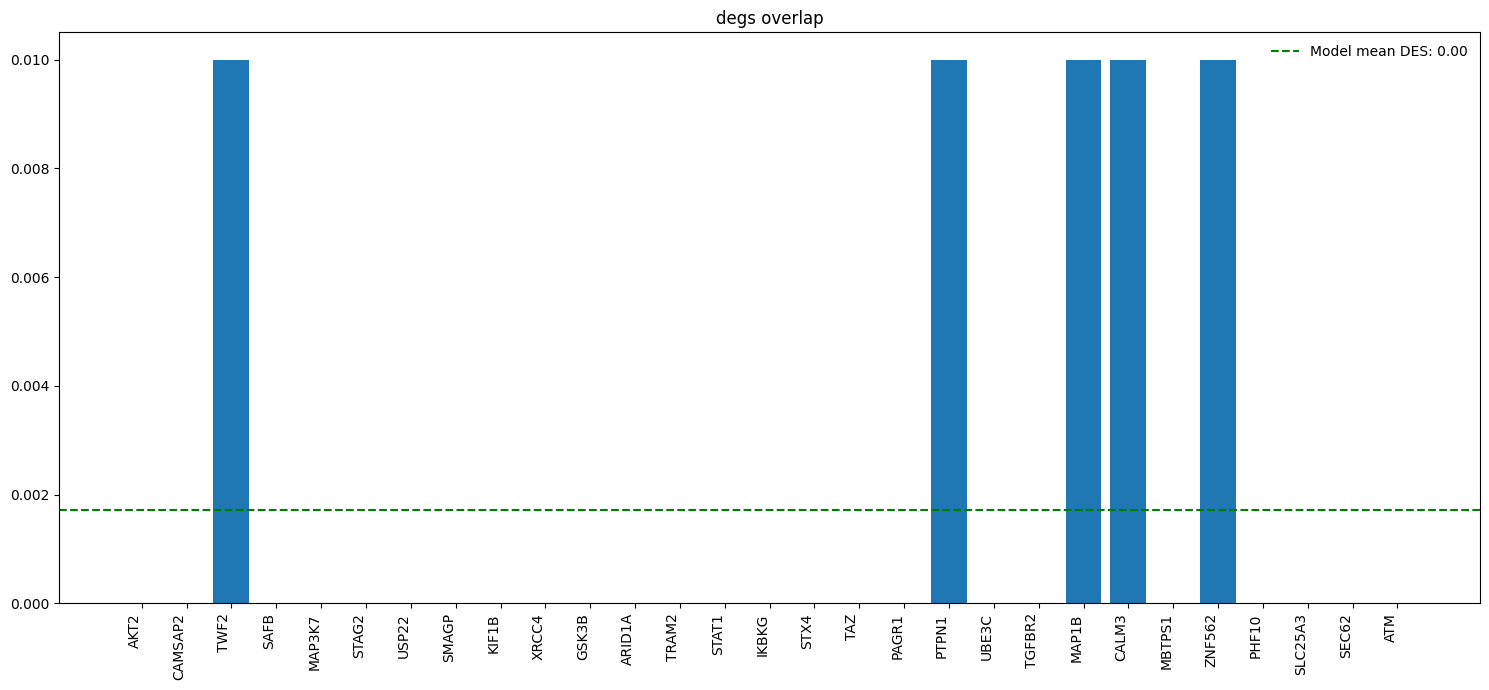

In [53]:
from val_scores import *
from visualization import eval_barplot

#model_results, baseline_results = calc_auprc(real_adata, pred_adata)
model_results = calc_common_degs(real_adata, pred_adata)
eval_barplot(model_results, 'degs overlap')

This is my custom and robus F1 classification score, still useful.

In [ ]:
from val_scores import RobustDES

des_calculator = RobustDES(lfc_threshold=0.3, alpha=0.01)
des_calculator.DES_confusion_matrix(perts,real_adata,pred_adata,'target_gene', 'non-targeting')

### Benchmark new
taken from paper [Benchmarking algorithms for generalizable single-cell perturbation response prediction](https://www.nature.com/articles/s41592-025-02980-0)

***

### **Additional stuff**

In [ ]:
pred_adata.write('results/pred_adata.h5ad')
real_adata.write('results/real_adata.h5ad')

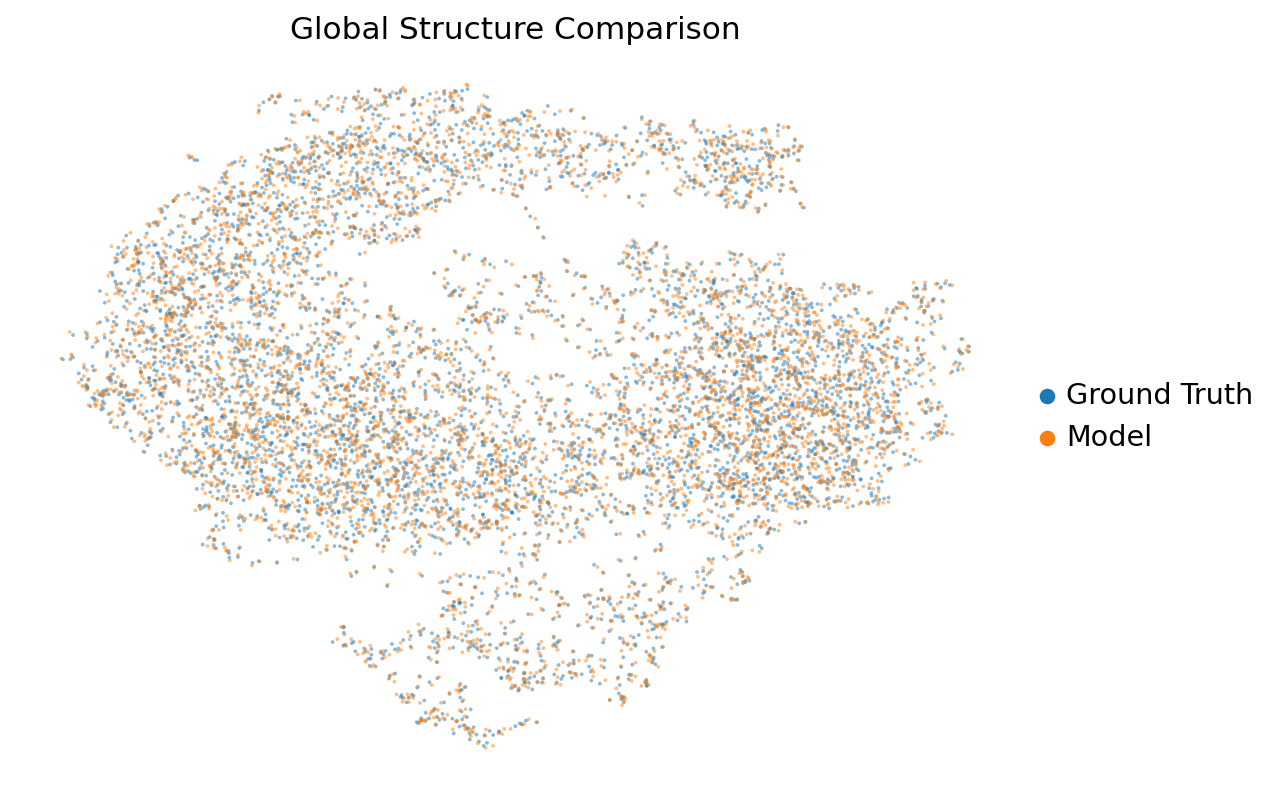

In [79]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Label your datasets
real_adata.obs['dataset'] = 'Ground Truth'
pred_adata.obs['dataset'] = 'Model'

# 2. Concatenate them
adata_combined = real_adata[real_adata.obs['target_gene']=='non-targeting'].concatenate(
    pred_adata[pred_adata.obs['target_gene']=='non-targeting'],
    batch_key='source',
    index_unique='-'
)

# 3. Compute embeddings
sc.pp.pca(adata_combined)
sc.pp.neighbors(adata_combined)
sc.tl.umap(adata_combined)   # <-- FIXED

# 4. Plot
sc.set_figure_params(figsize=(8, 6))
sc.pl.umap(
    adata_combined,
    color=['dataset'],
    alpha=0.5,
    title="Global Structure Comparison",
    frameon = False,
    #save = "umap.pdf"
)


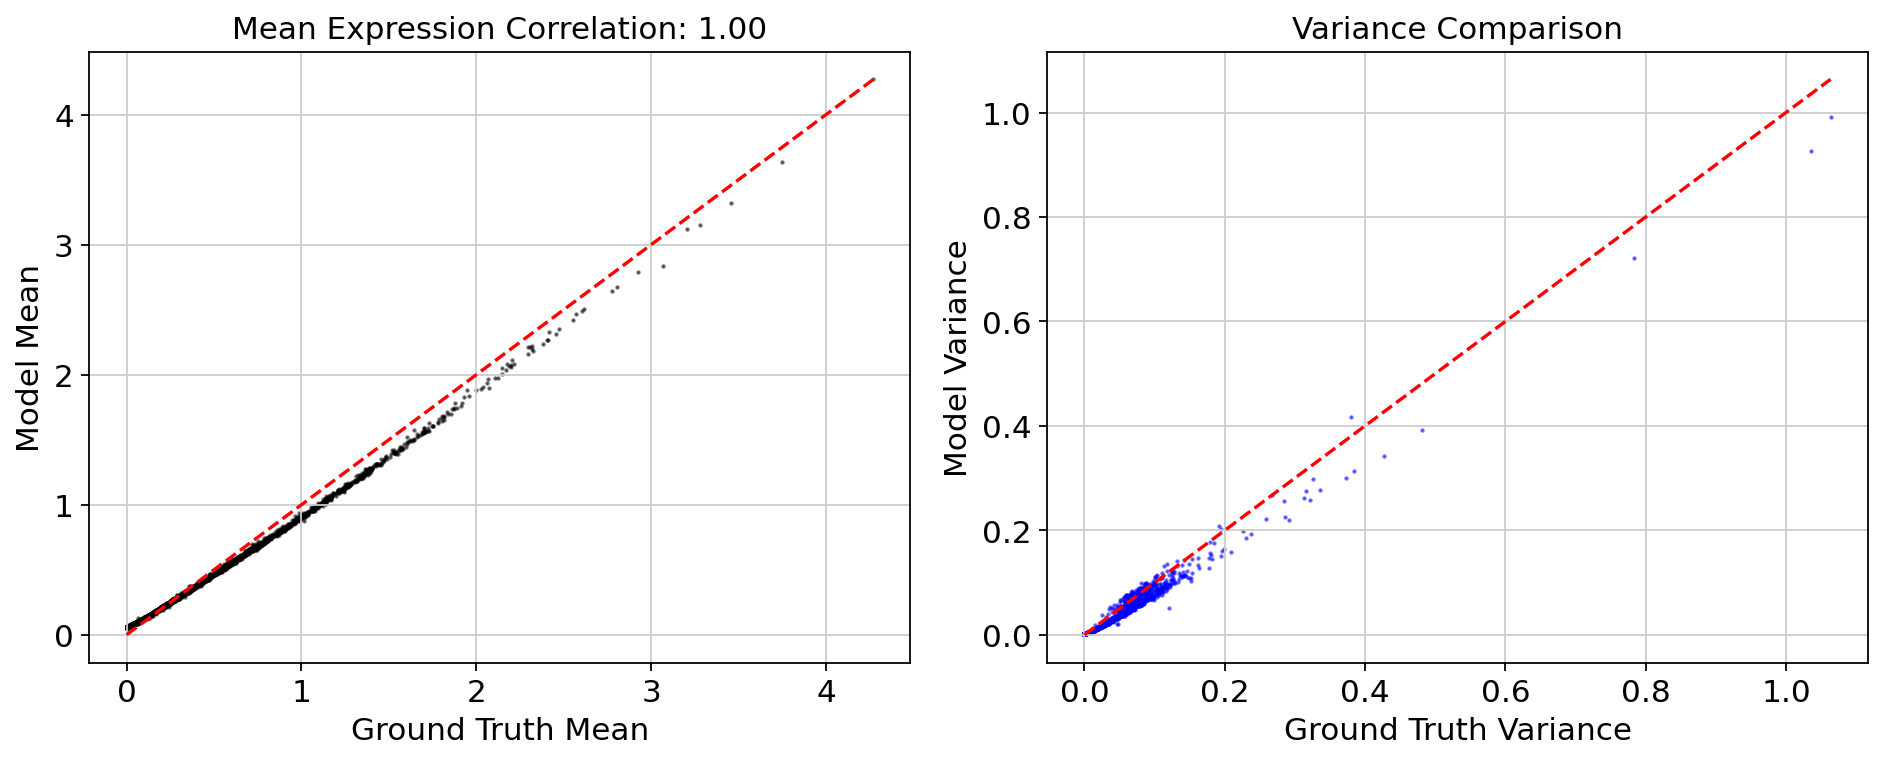

In [ ]:
import numpy as np
import seaborn as sns

# Helper function to get mean expression per gene
def get_gene_metrics(adata):
    # Handle sparse matrices if necessary
    if hasattr(adata.X, "toarray"):
        X = adata.X.toarray()
    else:
        X = adata.X
    
    mean_exp = np.mean(X, axis=0)
    var_exp = np.var(X, axis=0)
    return mean_exp, var_exp

gt_mean, gt_var = get_gene_metrics(real_adata)
model_mean, model_var = get_gene_metrics(pred_adata)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Mean Expression
ax[0].scatter(gt_mean, model_mean, s=1, alpha=0.5, c='k')
ax[0].plot([0, max(gt_mean)], [0, max(gt_mean)], 'r--') # Diagonal
ax[0].set_xlabel("Ground Truth Mean")
ax[0].set_ylabel("Model Mean")
ax[0].set_title(f"Mean Expression Correlation: {np.corrcoef(gt_mean, model_mean)[0,1]:.2f}")

# Plot 2: Variance (Dispersion)
ax[1].scatter(gt_var, model_var, s=1, alpha=0.5, c='b')
ax[1].plot([0, max(gt_var)], [0, max(gt_var)], 'r--') # Diagonal
ax[1].set_xlabel("Ground Truth Variance")
ax[1].set_ylabel("Model Variance")
ax[1].set_title("Variance Comparison")

plt.tight_layout()
plt.show()

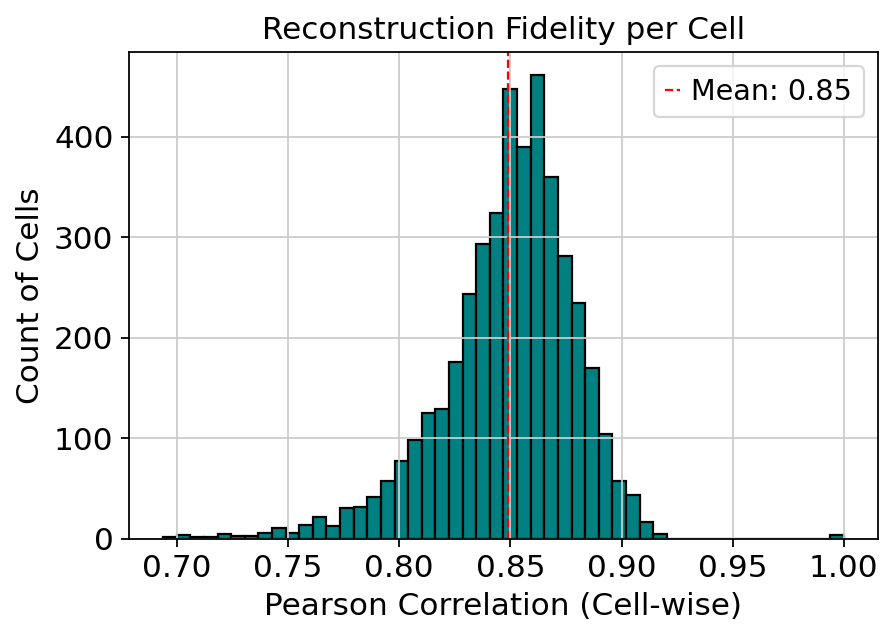

In [ ]:
from scipy.stats import pearsonr

correlations = []
n_cells = pred_adata.shape[0]

# Convert to dense once if memory allows, or iterate carefully
X_gt = real_adata.X if not hasattr(real_adata.X, "toarray") else real_adata.X.toarray()
X_model = pred_adata.X if not hasattr(pred_adata.X, "toarray") else pred_adata.X.toarray()

for i in range(n_cells):
    # Calculate correlation for cell i
    corr, _ = pearsonr(X_gt[i], X_model[i])
    correlations.append(corr)

# Plot Histogram of Correlations
plt.figure(figsize=(6, 4))
plt.hist(correlations, bins=50, color='teal', edgecolor='black')
plt.xlabel("Pearson Correlation (Cell-wise)")
plt.ylabel("Count of Cells")
plt.title("Reconstruction Fidelity per Cell")
plt.axvline(np.mean(correlations), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(correlations):.2f}')
plt.legend()
plt.show()

***

### **Generative model - please work**

In [ ]:
def generate_adata(perts_x_ncells, model, gene_to_idx, var_names):
    prediction_list = []
    obs_gene_list = []

    # for each perturbation....
    for pert in perts_x_ncells.keys():
        if pert != "non-targeting":
            print(pert)

            # how many cells are in the real data and I have to generate with the generative model?
            n_cells = perts_x_ncells[pert]

            # index corresponding to the pert
            ko_gene_idx = gene_to_idx[pert]

            # generate n_cell perturbed cells
            for j in range(n_cells):
                _, predicted_full_gex = model.generative_prediction(ko_gene_idx)
                predicted_full_gex = predicted_full_gex.reshape(1,-1).detach().cpu()
                prediction_list.append(predicted_full_gex.numpy()) 
                obs_gene_list.append(pert)

    # Stack all (1, N) vectors → shape (total_cells, N)
    X = np.vstack(prediction_list)

    # Build obs dataframe
    obs = pd.DataFrame({
        "target_gene": obs_gene_list
    })

    # Build var dataframe (gene names)
    var = pd.DataFrame(index=var_names)   # length N list of gene names

    pred_adata = ad.AnnData(X=X, obs=obs, var=var)
    return pred_adata

In [ ]:
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= 200]

# Remove 'non-targeting'
gene_counts_dict = counts.drop('non-targeting').to_dict()
del counts

pred_adata2 = generate_adata(gene_counts_dict, model, gene_to_idx, real_adata.var_names)
pred_adata2


***

### Other analysis

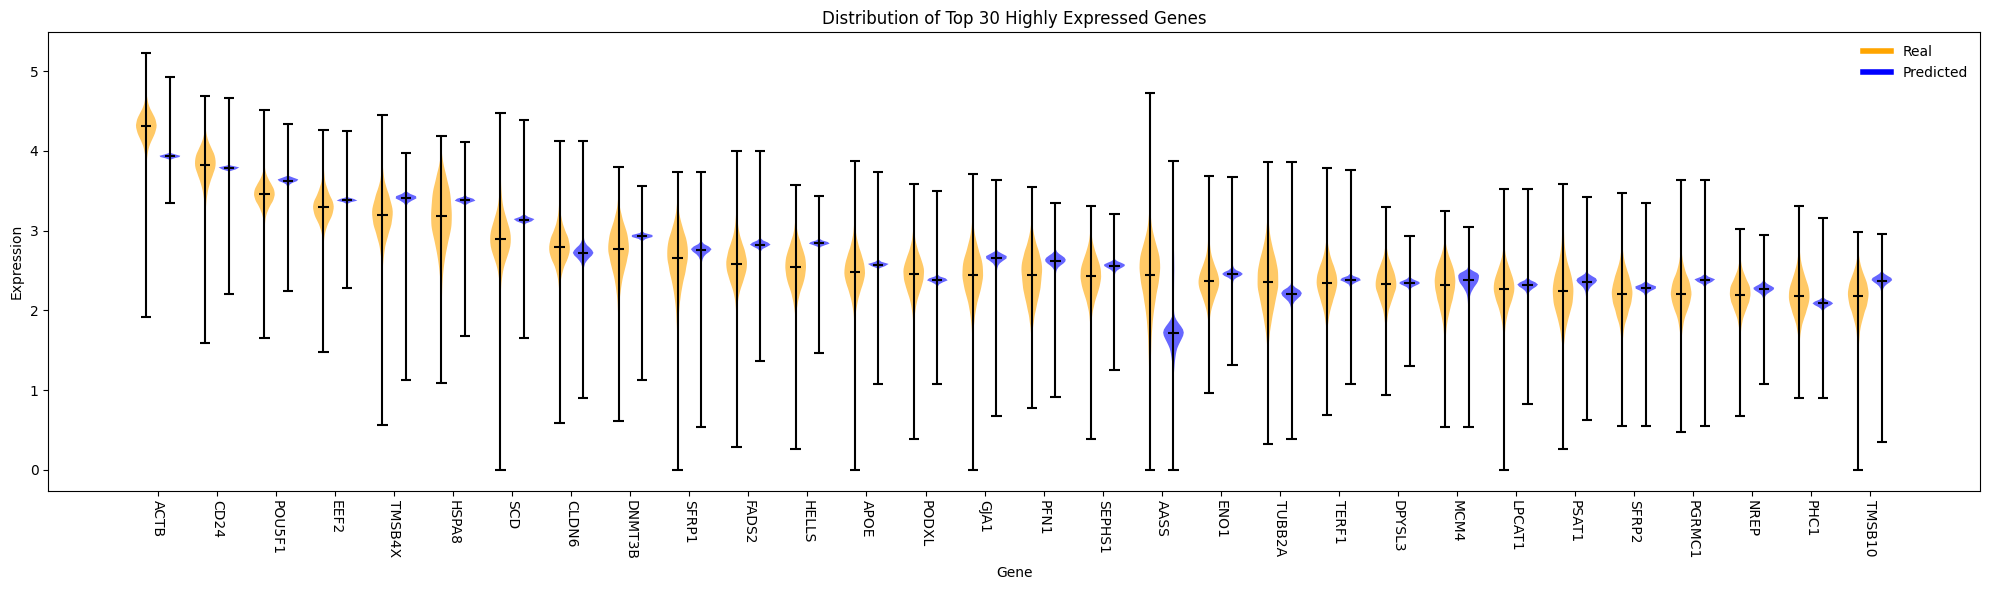

In [55]:
from visualization import plot_top_highly_expressed_genes
from visualization import plot_top_highly_variable_genes

plot_top_highly_expressed_genes(30, real_adata, pred_adata, False)

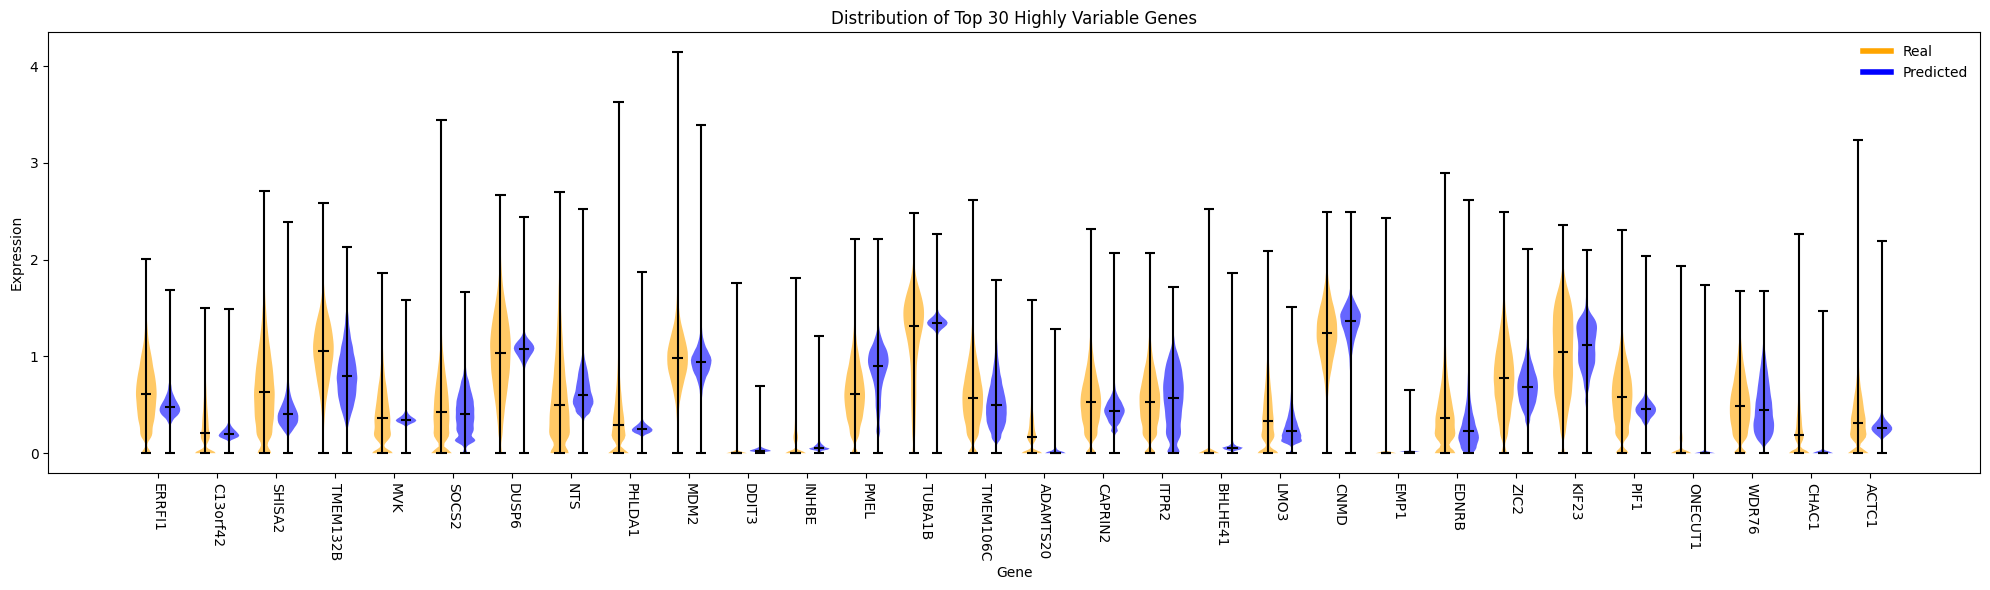

In [56]:
plot_top_highly_variable_genes(30, real_adata, pred_adata, False)

**let's try with just the DE genes**

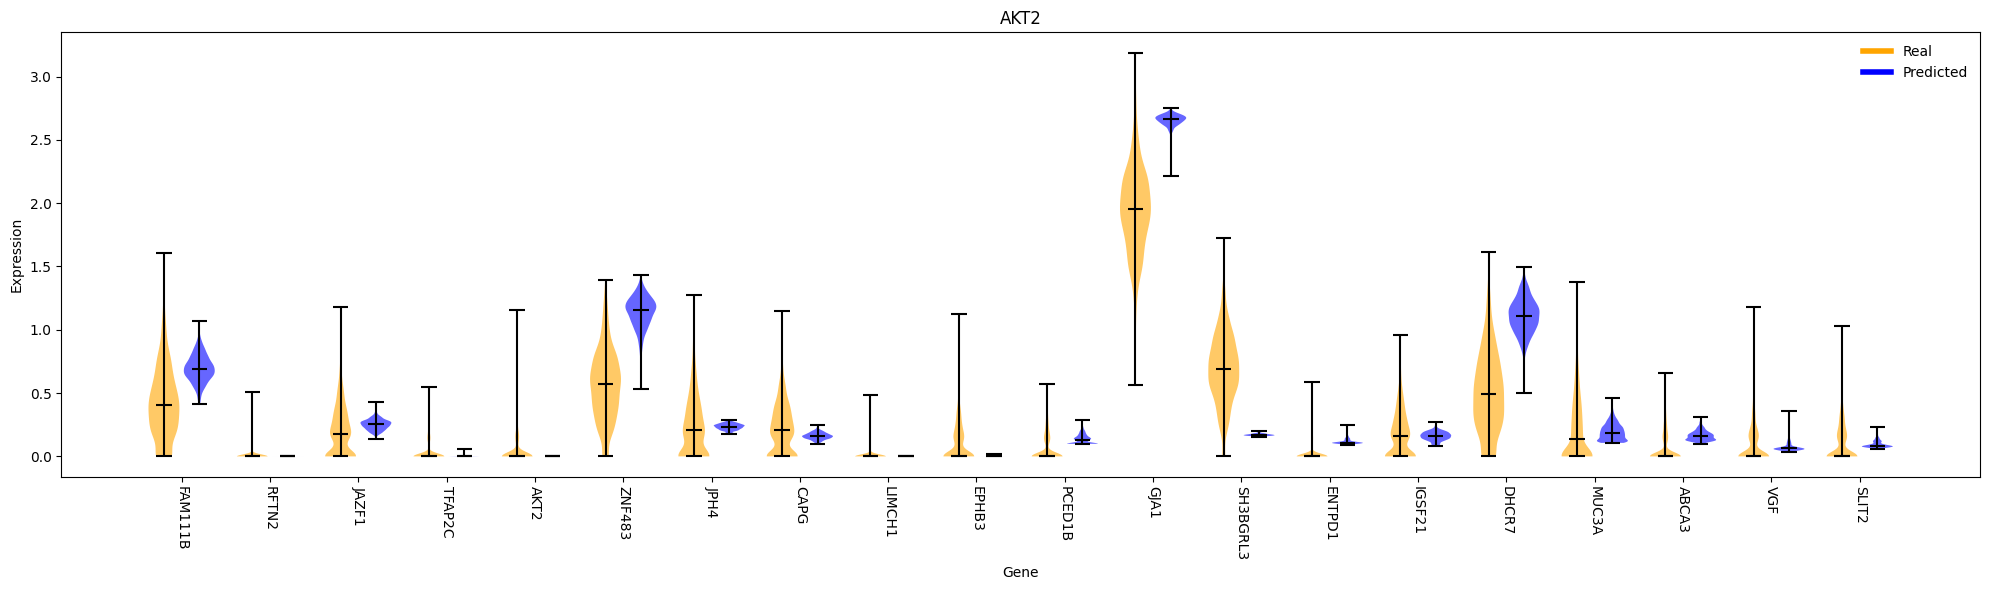

In [66]:
from val_scores import RobustDES
from visualization import plot_violins_redictions_selected_genes


des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

max_de_genes = 20
perturb_label = 'AKT2'
DE_genes, _ = des_calculator.get_de_genes(real_adata, 'target_gene', perturb_label, 'non-targeting')
list_DE_genes = list(set(DE_genes.index))
if len(list_DE_genes)>max_de_genes:
    list_DE_genes = list(set(DE_genes.loc[DE_genes['logfoldchanges'].abs().sort_values(ascending=False).index[:max_de_genes]].index))

plot_violins_redictions_selected_genes(list_DE_genes, 
    real_adata[real_adata.obs['target_gene']==perturb_label], 
    pred_adata[pred_adata.obs['target_gene']==perturb_label], 
    False, 
    perturb_label
)


In [43]:
import seaborn as sns
from scipy.stats import wasserstein_distance, pearsonr
from sklearn.metrics import r2_score

In [44]:
def plot_lfc_correlation(real_adata, pred_adata, perturb_list, des_calculator, 
                         target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Plots a scatter plot of Real vs Predicted Log2 Fold Changes for DE genes across multiple perturbations.
    """
    all_real_lfcs = []
    all_pred_lfcs = []
    
    # Get the real control cells to serve as the baseline for predicted LFC
    real_ctrl_adata = real_adata[real_adata.obs[target_col] == ctrl_label]
    
    for perturb in perturb_list:
        # 1. Get Real DE genes and their Real LFCs
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        if de_df.empty:
            continue
            
        de_genes = de_df.index.tolist()
        real_lfc = de_df['logfoldchanges'].values
        
        # 2. Calculate Predicted LFCs for these specific DE genes
        pred_perturb_adata = pred_adata[pred_adata.obs[target_col] == perturb]
        
        # Extract matrices
        pred_X = pred_perturb_adata[:, de_genes].X
        ctrl_X = real_ctrl_adata[:, de_genes].X
        
        if hasattr(pred_X, "toarray"): pred_X = pred_X.toarray()
        if hasattr(ctrl_X, "toarray"): ctrl_X = ctrl_X.toarray()
            
        # Means per gene (add small pseudocount to avoid log(0))
        mean_pred = pred_X.mean(axis=0) + 1e-9
        mean_ctrl = ctrl_X.mean(axis=0) + 1e-9
        
        # Log2 fold change: log2(Predicted Perturb / Real Control)
        pred_lfc = np.log2(mean_pred / mean_ctrl)
        
        all_real_lfcs.extend(real_lfc)
        all_pred_lfcs.extend(pred_lfc)
        
    # Calculate global Pearson correlation
    r_val, p_val = pearsonr(all_real_lfcs, all_pred_lfcs)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.scatterplot(x=all_real_lfcs, y=all_pred_lfcs, alpha=0.5, s=10, edgecolor=None, color='#1f77b4', ax=ax)
    
    # Plot identity line (y = x)
    min_val = min(min(all_real_lfcs), min(all_pred_lfcs))
    max_val = max(max(all_real_lfcs), max(all_pred_lfcs))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=0.5, label='Perfect Prediction (y=x)')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_xlabel('Ground Truth LFC (Real Perturbed vs Real Control)')
    ax.set_ylabel('Predicted LFC (Pred Perturbed vs Real Control)')
    ax.set_title(f'Global LFC Correlation\nPearson R = {r_val:.3f} (p={p_val:.2e})')
    ax.legend(frameon=False)
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('LFC_Correlation_Plot.pdf')
    plt.show()

In [45]:
def plot_wasserstein_distances(real_adata, pred_adata, perturb_list, des_calculator, 
                               target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Calculates the average Wasserstein distance of DE genes between real and predicted cells for each perturbation.
    """
    perturb_distances = {}
    
    for perturb in perturb_list:
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        if de_df.empty:
            continue
            
        de_genes = de_df.index.tolist()
        
        # Isolate the cells for this specific perturbation
        real_vals = real_adata[real_adata.obs[target_col] == perturb, de_genes].X
        pred_vals = pred_adata[pred_adata.obs[target_col] == perturb, de_genes].X
        
        if hasattr(real_vals, "toarray"): real_vals = real_vals.toarray()
        if hasattr(pred_vals, "toarray"): pred_vals = pred_vals.toarray()
            
        # Calculate Wasserstein distance for each gene independently
        w_dists = [wasserstein_distance(real_vals[:, i], pred_vals[:, i]) for i in range(len(de_genes))]
        
        # Store the average distance for this perturbation
        perturb_distances[perturb] = np.mean(w_dists)
        
    # Convert to DataFrame for easy Seaborn plotting and sorting
    df_dists = pd.DataFrame(list(perturb_distances.items()), columns=['Perturbation', 'Avg_Wasserstein_Distance'])
    df_dists = df_dists.sort_values('Avg_Wasserstein_Distance', ascending=False) # Highest distance = worst prediction
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df_dists, x='Perturbation', y='Avg_Wasserstein_Distance', color='salmon', ax=ax)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel('Average Wasserstein Distance (Lower is better)')
    ax.set_xlabel('Perturbations')
    ax.set_title('Distribution Match between Real and Predicted Perturbations')
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('Wasserstein_Distances.pdf')
    plt.show()

In [46]:
def plot_delta_mean_r2(real_adata, pred_adata, perturb_list, des_calculator, 
                       target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Calculates the R-squared score between the real and predicted *change in mean expression* (Delta) of DE genes relative to the control state.
    """
    perturb_r2 = {}
    
    # Baseline: Real control cells
    real_ctrl_adata = real_adata[real_adata.obs[target_col] == ctrl_label]
    
    for perturb in perturb_list:
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        
        # R2 score requires at least 2 genes to compute variance.
        if de_df.empty or len(de_df) < 2:
            continue
            
        de_genes = de_df.index.tolist()
        
        # Isolate matrices
        real_perturb_X = real_adata[real_adata.obs[target_col] == perturb, de_genes].X
        pred_perturb_X = pred_adata[pred_adata.obs[target_col] == perturb, de_genes].X
        real_ctrl_X = real_ctrl_adata[:, de_genes].X
        
        if hasattr(real_perturb_X, "toarray"): real_perturb_X = real_perturb_X.toarray()
        if hasattr(pred_perturb_X, "toarray"): pred_perturb_X = pred_perturb_X.toarray()
        if hasattr(real_ctrl_X, "toarray"): real_ctrl_X = real_ctrl_X.toarray()
        
        # Calculate means
        real_perturb_means = real_perturb_X.mean(axis=0)
        pred_perturb_means = pred_perturb_X.mean(axis=0)
        real_ctrl_means = real_ctrl_X.mean(axis=0)
        
        # CALCULATE DELTAS (Effect Size)
        real_delta = real_perturb_means - real_ctrl_means
        pred_delta = pred_perturb_means - real_ctrl_means
        
        # Calculate R-squared score on the deltas
        r2 = r2_score(real_delta, pred_delta)
        perturb_r2[perturb] = r2
        
    # Convert to DataFrame
    df_r2 = pd.DataFrame(list(perturb_r2.items()), columns=['Perturbation', 'R2_Score_of_Delta'])
    df_r2 = df_r2.sort_values('R2_Score_of_Delta', ascending=False)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df_r2, x='Perturbation', y='R2_Score_of_Delta', color='mediumseagreen', ax=ax)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel('$R^2$ Score of Delta (Higher is better)')
    ax.set_xlabel('Perturbations')
    ax.set_title('$R^2$ of Perturbation Effect (Delta) per Perturbation')
    ax.axhline(0, color='black', lw=1) # Baseline at 0 (worse than 0 means predicting the mean delta is better)
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('Delta_R2_Scores.pdf')
    plt.show()

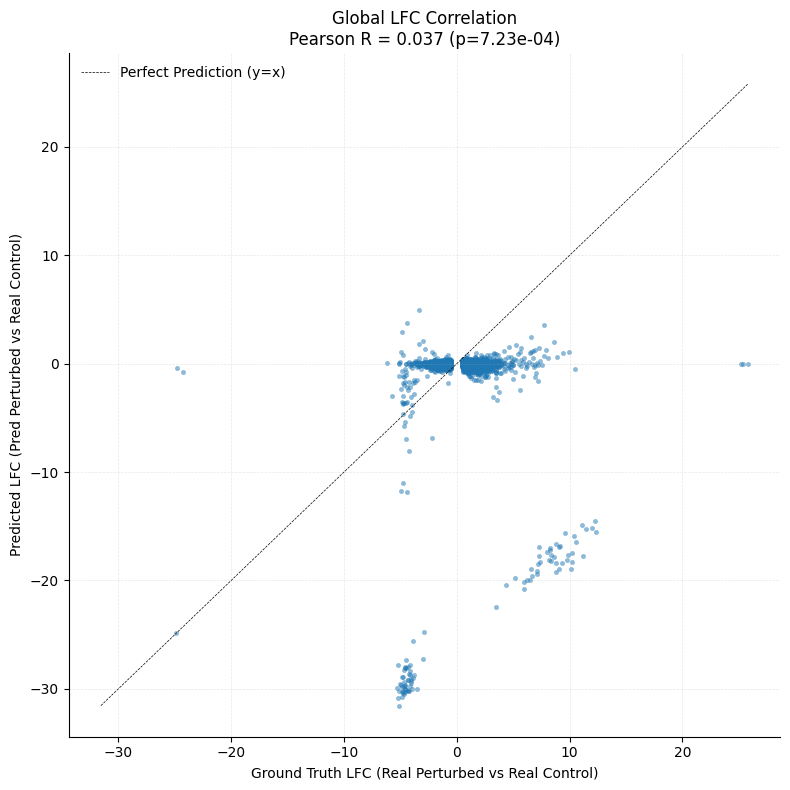

In [47]:
# Remove the control label from your perturbation list so we don't calculate DE for control vs control
perturb_list = [p for p in real_adata.obs['target_gene'].unique() if p != 'non-targeting']

# Option A: Plot Global LFC Scatter
plot_lfc_correlation(real_adata, pred_adata, perturb_list, des_calculator, save=False)


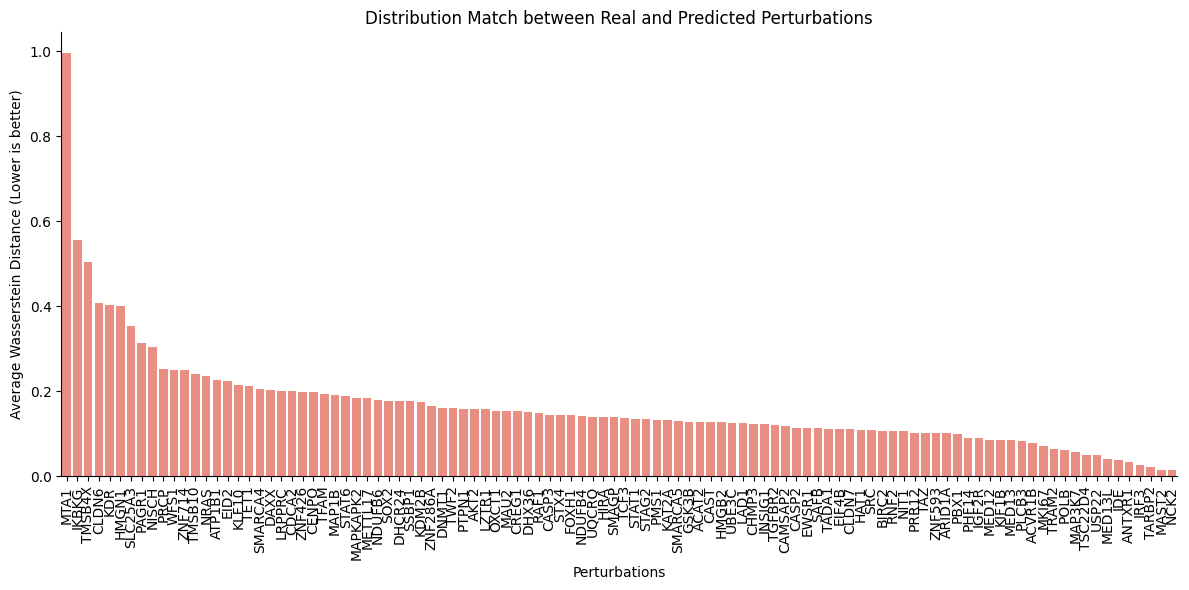

In [48]:

# Option B: Plot Wasserstein Distance Bar Chart
plot_wasserstein_distances(real_adata, pred_adata, perturb_list, des_calculator, save=False)


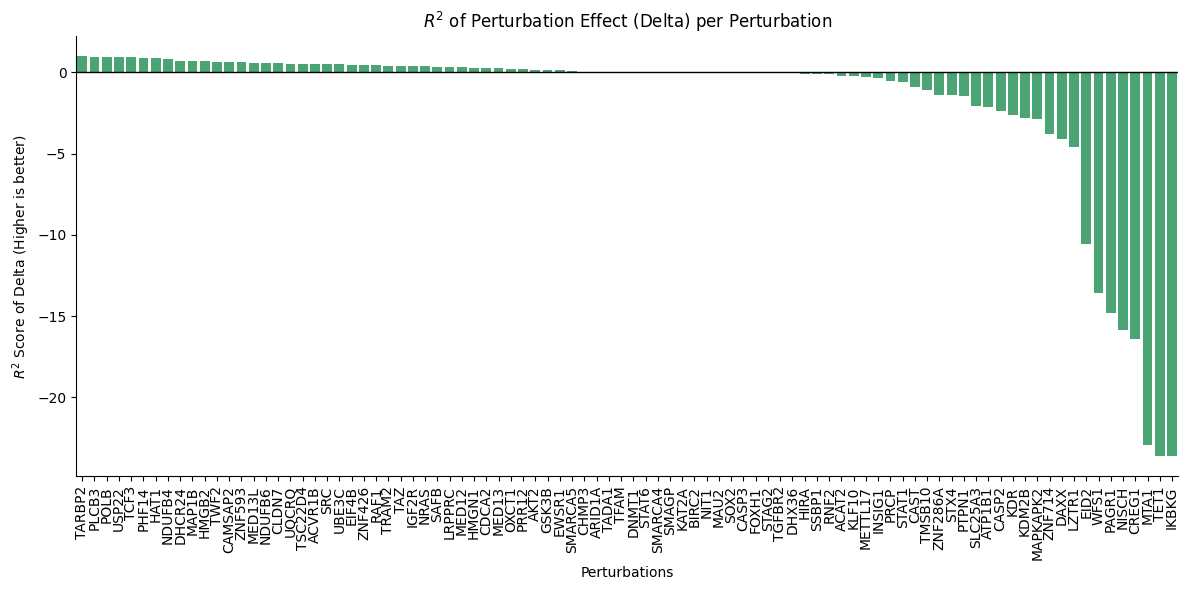

In [49]:
# Option C: Plot R2 Bar Chart
plot_delta_mean_r2(real_adata, pred_adata, perturb_list, des_calculator, save=False)